# Data Import

In [1]:
# data analysis
import numpy as np
import pandas as pd

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# model preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# data viz
import seaborn as sns
import matplotlib.pyplot as plt

# the data
from sklearn.datasets import load_iris
iris = load_iris()

# show output of data
print("*"*30)
print(iris.data.shape,iris.target.shape)
print("*"*30)
print(iris.feature_names)
print("*"*30)
print(iris.target_names)
print("*"*30)

******************************
(150, 4) (150,)
******************************
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
******************************
['setosa' 'versicolor' 'virginica']
******************************


# Probalistic Modelling

Within this section, I will explore what this type of modelling represents and its applications wihtin Data Science. This is my attempt to conceptualise what I have read & understoof in Bishop's Machine Learning and Pattern Recognition Chapter 1.

Firstly, I will train a simple Logistic Regression then plot the Posterior Distribution of the model based off the features employed. I will then interpret what this Distribution means in the application context and key learning to take away.

In [2]:
# focus solely on 2 classes. I will increase to three to see what happens!
mask = iris.target < 2
x = iris.data[mask, :2] # only 2 features
y = iris.target[mask]

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)


# apply standarization to the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 2))
X_test = scaler.transform(X_test.reshape(-1, 2))



print("*"*30)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("*"*30)

******************************
Training set shape: (70, 2)
Test set shape: (30, 2)
******************************


In [3]:
def process_data_for_decision_boundary(model, X, y, model_name):
    # initiaite the log reg model and fit to training set
    model.fit(X_train, y_train)

    # we just want to predict the Posterior distribution, so i will just use predict_proba
    # get the boundaries of the data for plotting
    x_min, x_max = X[:, 0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:,1].max() + 0.5

    print("*"*30)
    print(f"Output of boundaries part 1: x_min={x_min}, x_max={x_max}, y_min={y_min}, y_max={y_max}")
    print("*"*30)

    # fist i want to create a meshgrid
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300), 
        np.linspace(y_min, y_max, 300)
    )

    print("*"*30)
    print(f"Output of boundaries part 2: x_min={x_min}, x_max={x_max}, y_min={y_min}, y_max={y_max}")
    print(f"Data shape: xx={xx.shape}, yy={yy.shape}")
    print("*"*30)

    # predict P(y=1|x) for each point in the meshgrid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    probability_space = model.predict_proba(grid_points)[:, 1]
    probability_space = probability_space.reshape(xx.shape)

    # show output
    print("*"*30)
    print(f"Output of probability space: shape={probability_space.shape}")
    print("*"*30)

    # plt the boundary
    plt_decision_boundary(xx, yy, probability_space, X, y,model_name)

def plt_decision_boundary(xx_in, yy_in, probability_space_in,X_train_in, y_train_in, model_name):
    # visualise the Decision regions and confidence gradients
    plt.figure(
        figsize=(10,8)
    )

    contour = plt.contourf(
        xx_in,
        yy_in,
        probability_space_in,
        alpha=0.8,
        cmap=plt.cm.coolwarm
    )
    
    # add colour bar
    plt.colorbar(
        contour,
        label="$P(y=1|x)$",
        boundaries=[0,1]
    )

    # add decision boundary
    plt.contour(
        xx_in,
        yy_in,
        probability_space_in,
        levels=[0.5],
        colors="black",
        linewidths=2,
        linestyles="--"
    )

    # add in the data points
    plt.scatter(
        X_train_in[:, 0],
        X_train_in[:, 1],
        c=y_train_in,
        edgecolors="k",
        cmap=plt.cm.coolwarm,
        s=100
    )
    
    # add in the title
    plt.title(
        f"{model_name} Decision Boundary and Confidence Gradient",
        fontsize=16,
        fontweight='bold',
        color='grey'
        )

    

******************************
Output of boundaries part 1: x_min=-2.2792444569228274, x_max=2.7771753543970124, y_min=-2.8323146358961413, y_max=2.7573808323332143
******************************
******************************
Output of boundaries part 2: x_min=-2.2792444569228274, x_max=2.7771753543970124, y_min=-2.8323146358961413, y_max=2.7573808323332143
Data shape: xx=(300, 300), yy=(300, 300)
******************************
******************************
Output of probability space: shape=(300, 300)
******************************


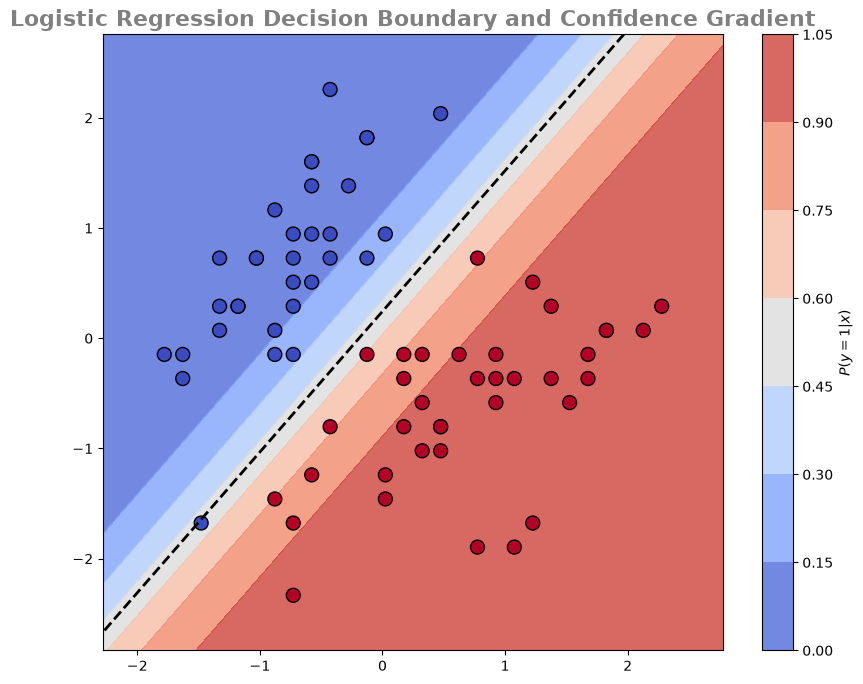

In [4]:
# list of penalties to test
log_reg=LogisticRegression()
process_data_for_decision_boundary(log_reg, X_train, y_train, "Logistic Regression")


******************************
Output of boundaries part 1: x_min=-2.2792444569228274, x_max=2.7771753543970124, y_min=-2.8323146358961413, y_max=2.7573808323332143
******************************
******************************
Output of boundaries part 2: x_min=-2.2792444569228274, x_max=2.7771753543970124, y_min=-2.8323146358961413, y_max=2.7573808323332143
Data shape: xx=(300, 300), yy=(300, 300)
******************************
******************************
Output of probability space: shape=(300, 300)
******************************
******************************
Output of boundaries part 1: x_min=-2.2792444569228274, x_max=2.7771753543970124, y_min=-2.8323146358961413, y_max=2.7573808323332143
******************************
******************************
Output of boundaries part 2: x_min=-2.2792444569228274, x_max=2.7771753543970124, y_min=-2.8323146358961413, y_max=2.7573808323332143
Data shape: xx=(300, 300), yy=(300, 300)
******************************
**************************

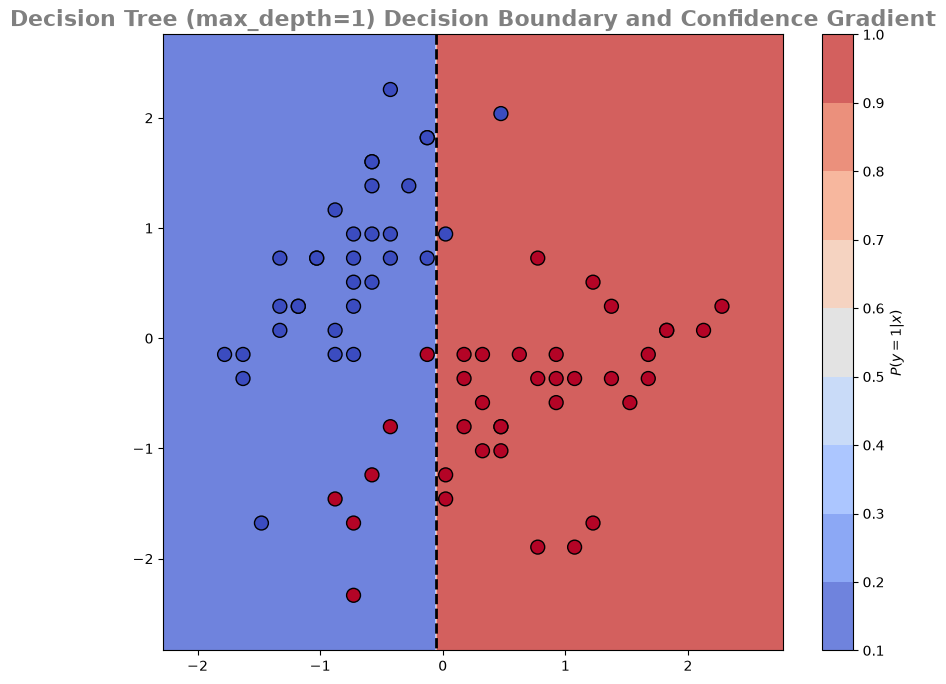

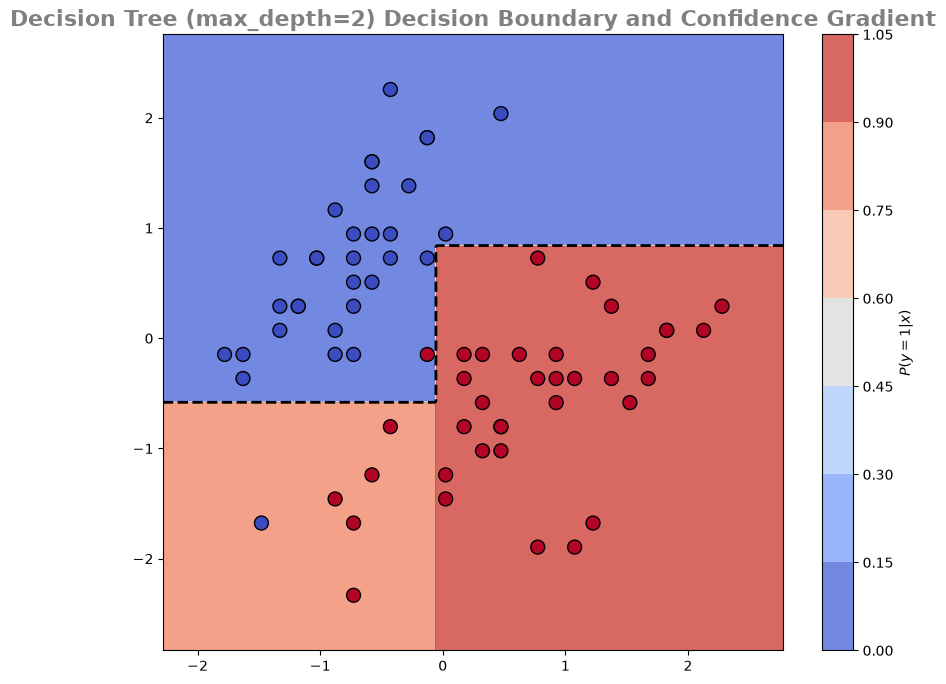

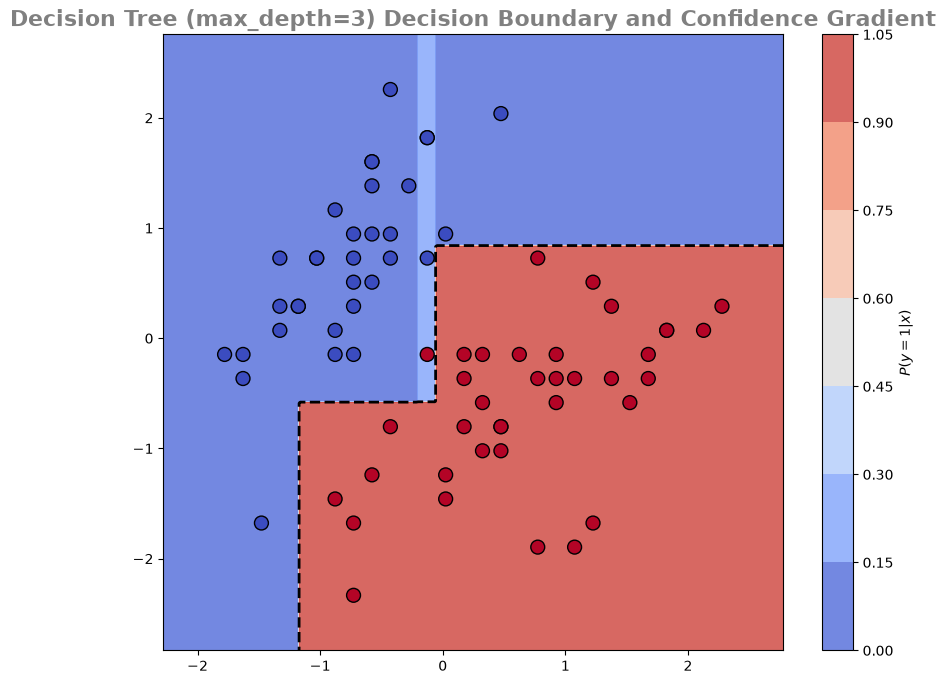

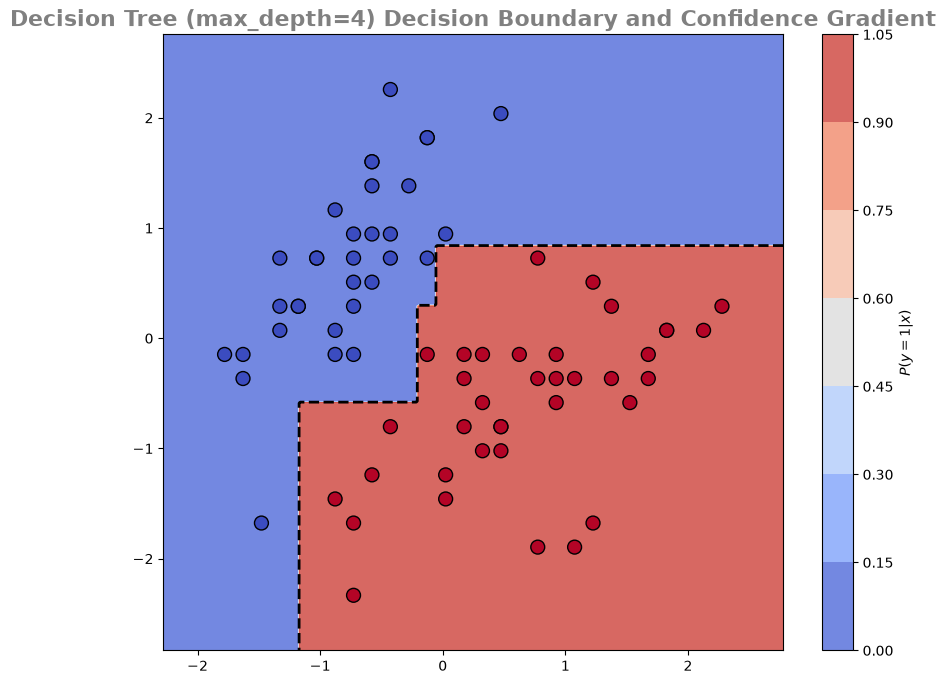

In [5]:
# now lets see when we change to a Decision Tree Classifier and change the max depth of the tree.
for i in range(1,5):
    process_data_for_decision_boundary(DecisionTreeClassifier(max_depth=i), X_train, y_train, f"Decision Tree (max_depth={i})")

c:\Users\Charl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Charl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Charl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


******************************
Output of boundaries part 1: x_min=-2.2792444569228274, x_max=2.7771753543970124, y_min=-2.8323146358961413, y_max=2.7573808323332143
******************************
******************************
Output of boundaries part 2: x_min=-2.2792444569228274, x_max=2.7771753543970124, y_min=-2.8323146358961413, y_max=2.7573808323332143
Data shape: xx=(300, 300), yy=(300, 300)
******************************
******************************
Output of probability space: shape=(300, 300)
******************************
******************************
Output of boundaries part 1: x_min=-2.2792444569228274, x_max=2.7771753543970124, y_min=-2.8323146358961413, y_max=2.7573808323332143
******************************
******************************
Output of boundaries part 2: x_min=-2.2792444569228274, x_max=2.7771753543970124, y_min=-2.8323146358961413, y_max=2.7573808323332143
Data shape: xx=(300, 300), yy=(300, 300)
******************************
**************************

c:\Users\Charl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


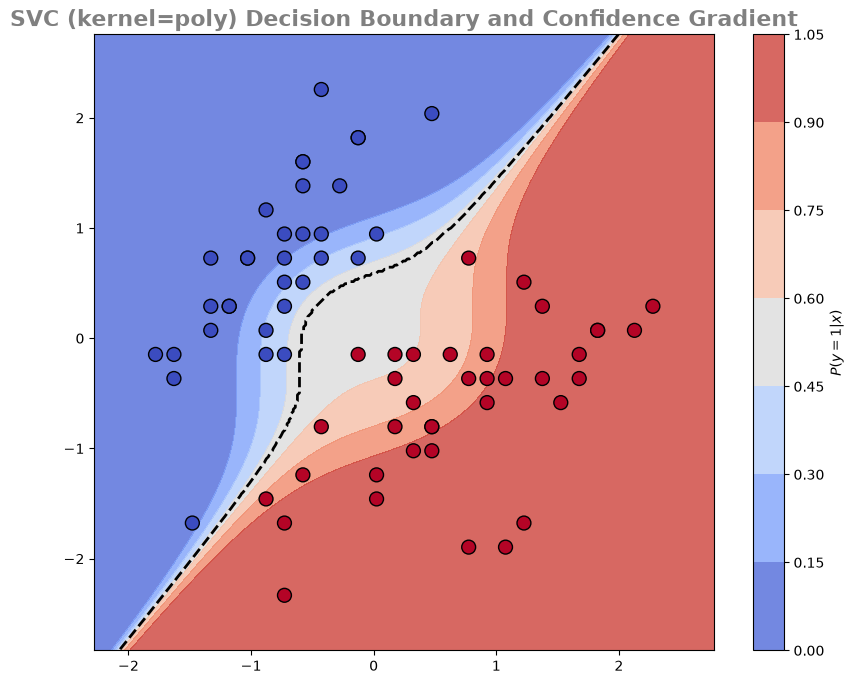

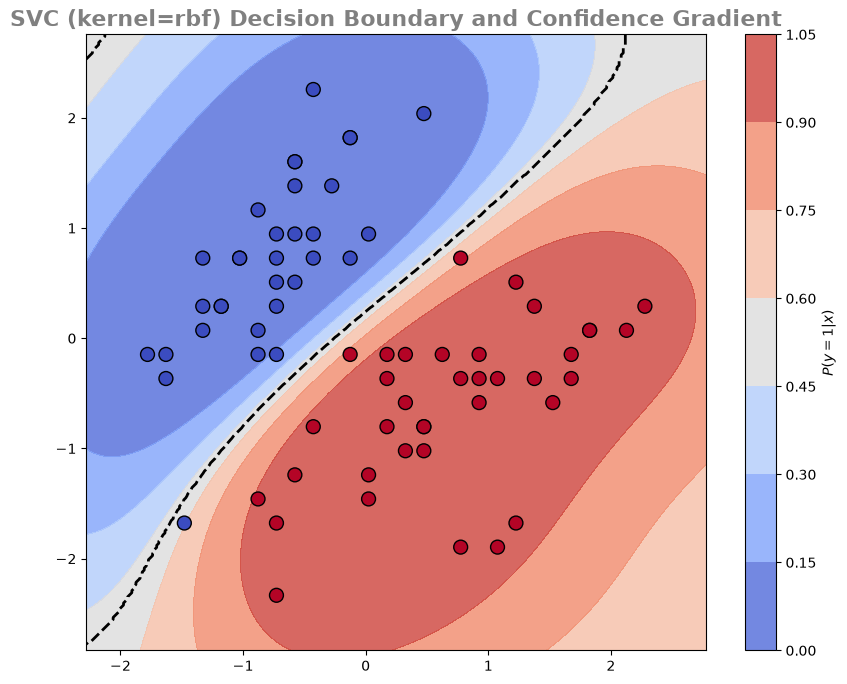

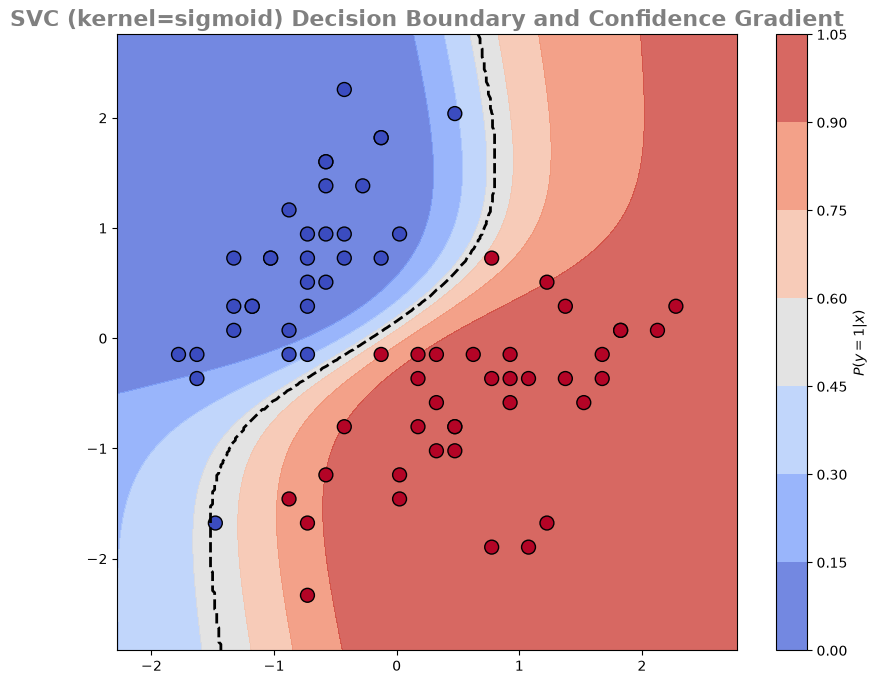

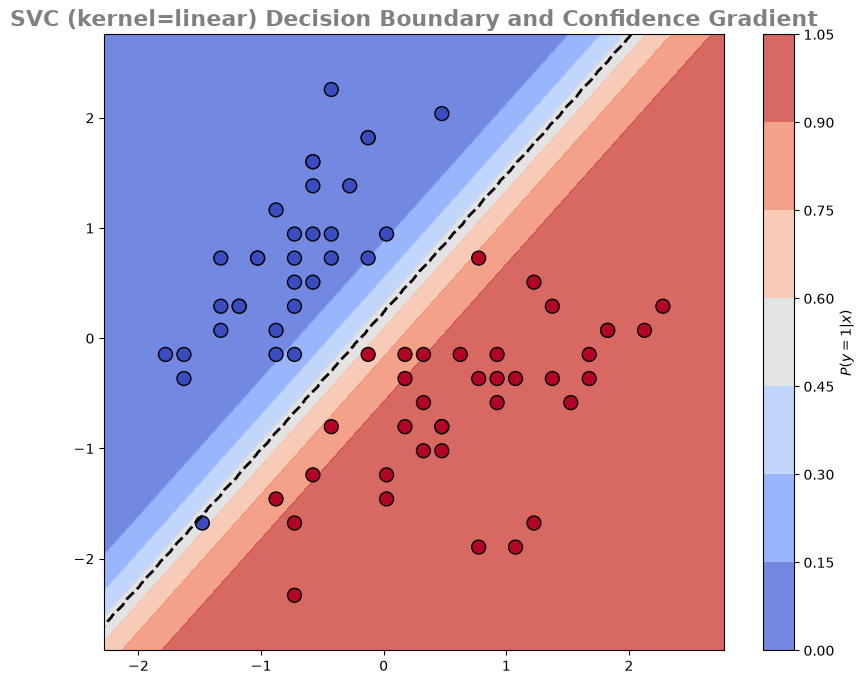

In [6]:
# now what happens when we go moe complex and use a SVC with a RBF kernel
for i in ['poly', 'rbf', 'sigmoid','linear']:
    process_data_for_decision_boundary(SVC(probability=True, kernel=i), X_train, y_train, f"SVC (kernel={i})")

# Maximum Likelihood Estimation Applied to Log Regression

MLE is very important in ML as each odels cost/loss function is derived from MLE in that you're trying to maximise P(x1,x2....xn|Theta). In other words, you're are to maximise the likelihood of observing the data given theta. In ML terms, we minimise Theta to increase the likelhood of observing the data (Your train and test sets!).

In [43]:


# produces p-hat
def sigmoid_function(t : float):
    return 1/(1+np.exp(-t))

#logit function
def linear_combination(X : np.array, theta : np.array, bias : float):
    return np.dot(theta, X) + bias

# create the cost function for logistic regression
def cost_function(X : np.array, y : np.array, theta : np.array, bias : float):
    m, n = X.shape
    # create cost sum var
    cost_sum = 0

    for i in range(m):
        # get the linear combiation of the features and weights
        z = linear_combination(X[i], theta, bias)

        # feed z into sigmoid function to get p-hat
        p_hat = sigmoid_function(z)

        # update the cost
        cost_sum += -y[i] * np.log(p_hat) + (1-y[i]) * np.log(1-p_hat)

    return (1/m) * cost_sum


# now we need to take the PDE to find the global minimum of the cost function. 
# We will do this by taking the partial derivatives of the cost function 
# with respect to theta and bias.

def gradient_function(X : np.array, y : np.array, theta : np.array, bias : float):
    m, n = X.shape
    # create zeros matrix for the gradients
    d_theta = np.zeros(n)
    d_bias = 0

    # iterate and take the pde
    for i in range(m):
        # get the linear combination of the features and weights
        z = linear_combination(X[i], theta, bias)

        # convert to p-hat
        p_hat = sigmoid_function(z)

        # take the gradient
        d_bias += (p_hat-y[i])

        # update the weights for each feature
        for j in range(n):
            d_theta[j] += (p_hat - y[i]) * X[i][j]
    
    # update the gradients by times by 1/m
    d_bias = (1/m) * d_bias
    d_theta = (1/m) * d_theta

    return d_theta, d_bias

# now we create a gradient decent function to update 
# the weights and bias based on the gradients we calculated above.

def gradient_decent(X : np.array, y : np.array, alpha : float, iterations : int):
    m, n = X.shape
    cost_values = list()
    # apply same logic with weight and bias
    theta = np.zeros(n)
    bias = 0

    # iterate through the number of iterations
    for i in range(iterations):
        
        # extract gradient values
        grad_theta, grad_bias = gradient_function(X, y, theta, bias)

        # input the gradient values into the update function to update the weights and bias
        theta = theta - alpha * grad_theta
        bias = bias - alpha * grad_bias

        # print the cost at each iteration to see if it is decreasing
        cost = cost_function(X, y, theta, bias)
        cost_values.append(cost)
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost}")

    # viz the cost function
    visulaise_the_log_loss(cost_values)
    
    # reurn the final weights and bias
    return theta, bias

# let make ther model to predict data
def predict(X : np.array, theta : np.array, bias : float):
    m, n = X.shape
    preds = np.zeros(m)

    for i in range(m):
        # get the linear combination of the features and weights
        z = linear_combination(X[i], theta, bias)

        # convert to p-hat
        p_hat = sigmoid_function(z)

        # return the predicted class based on p-hat
        preds[i] = 1 if p_hat >= 0.5 else 0
    
    return preds

def visulaise_the_log_loss(cost_list: list):
    """
    This function will simply visialse what is happening
    to our cost function as we step through the Gradient Decent
    iterations.
    """
    plt.figure(
        figsize=(10,8)
    )
    # show in line plot
    x_range = range(len(cost_list))
    sns.lineplot(
        x=x_range,
        y=cost_list,
        color='blue',
        label='Cost Function'
    )
    title =(
        "Cost Function over Gradient Descent Iterations\n"
        "$ \\mathcal{J(\\theta, b)} = \\sum_{i=1}^{m} [y_i \\log(p_i) + (1-y_i) \\log(1-p_i)] $"
    )
    #adjust the title and labels
    plt.title(
        title,
        fontsize=18,
        fontweight='bold',
        color='grey'
    )

    plt.xlabel(
        "Iterations",
        fontsize=14,
        fontweight='bold',
        color='grey'
    )

    plt.ylabel(
        "Cost Function Value",
        fontsize=14,
        fontweight='bold',
        color='grey'
    )

Iteration 0: Cost 0.03946596794037631
Iteration 100: Cost 0.029921858529602448
Iteration 200: Cost 0.025636138320638328
Iteration 300: Cost 0.023253076108248786
Iteration 400: Cost 0.02158707455164066
Iteration 500: Cost 0.02024408515787794
Iteration 600: Cost 0.019084689479560123
Iteration 700: Cost 0.018052999208107802
Iteration 800: Cost 0.01712224999398551
Iteration 900: Cost 0.016276723113351512


np.float64(1.0)

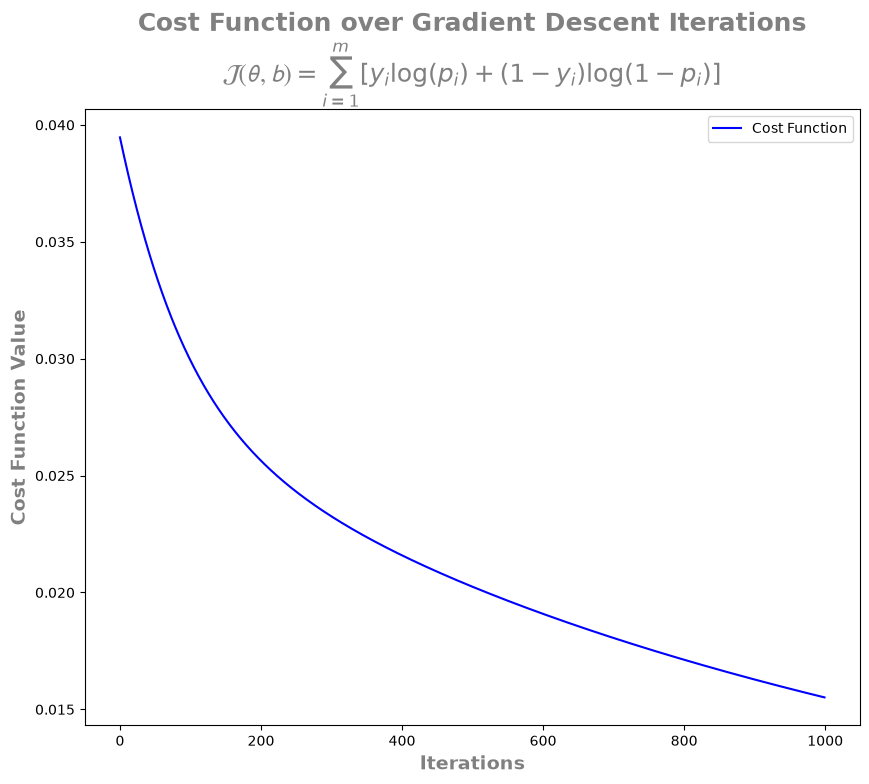

In [44]:
learning_rate = 0.01
iterations = 1000

final_theta, final_bias = gradient_decent(X_train, y_train, learning_rate, iterations)

#make the predictions
predictions = predict(X_test, final_theta, final_bias)

np.mean(predictions == y_test)